In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent  # go up from dev_notebooks/
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)

Repo root: /home/lonce/working/agent_projects/FargoNDacoder


In [2]:
import dac
from audiotools import AudioSignal
import torch
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import IPython.display as ipd

from core.rnndac_dataset import RNNDACLatentDataset, LatentDatasetConfig


In [3]:
DEVICE='cpu' # either 'cuda' or 'cpu'

print('__CUDNN VERSION:', torch.backends.cudnn.version())
print('__Number CUDA Devices:', torch.cuda.device_count())

if DEVICE == 'cuda' : 
    torch.cuda.is_available()
    torch.cuda.device_count()
    torch.cuda.get_device_properties(0).total_memory/1e9
    torch.cuda.device_count()
    print(f'memeory on cuda 0 is  {torch.cuda.get_device_properties(0).total_memory/1e9}')
    print(f'memeory on cuda 1 is  { torch.cuda.get_device_properties(1).total_memory/1e9}')
    print('__CUDA Device Name:',torch.cuda.get_device_name(0))
    print('__CUDA Device Total Memory [GB]:',torch.cuda.get_device_properties(0).total_memory/1e9)

device = torch.device(DEVICE) # if the docker was started with --gpus all, then can choose here.
print(f'Device is {device}')

model_path = dac.utils.download(model_type="44khz") 
print(f'Model is stored here: {model_path}')
model = dac.DAC.load(model_path)

__CUDNN VERSION: 90701
__Number CUDA Devices: 1
Device is cpu
Model is stored here: /home/lonce/.cache/descript/dac/weights_44khz_8kbps_0.0.1.pth


/home/lonce/miniconda3/envs/basicaudio/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [4]:
# PARAMETERS

In [5]:

hf_dataset_path = "/slowdisk/data/DAC/pitchglidesATriangle5octaves/Aglides/hf_dataset"


In [6]:
# load the dataset, and grab the first item

In [7]:
cfg = LatentDatasetConfig(
    dataset_path=hf_dataset_path,
    sequence_length=128,
    n_q=9,
    clamp_val=15,
    files_per_sequence=4,
)
#create dataset
ds = RNNDACLatentDataset(cfg, split="train", device="cpu")
x = ds[0]

print(x["latents"].shape)
print(x["targets"].shape)
print(x["cond"].shape)

torch.Size([128, 72])
torch.Size([128, 9])
torch.Size([128, 1])


In [8]:
# HELPER FUNCTIONS

In [9]:
def reconstruct_audio_from_codes(model, codes_TN):
    """
    codes_TN: [T, n_q] integer codes
    returns: audio tensor [samples]
    """
    codes_NT = codes_TN.T.unsqueeze(0).to(torch.long)   # [1, n_q, T]

    with torch.no_grad():
        z_q, *_ = model.quantizer.from_codes(codes_NT)
        audio = model.decode(z_q)   # typically [1, 1, samples]

    return audio.squeeze().cpu()



def reconstruct_audio_from_dataset_latents(model, latents_stacked_TD, clamp_val=15.0):
    """
    latents_stacked_TD: [T, n_q*8], normalized/clamped to [-1,1]
    returns: audio tensor [samples]
    """
    latents = latents_stacked_TD * clamp_val                  # un-normalize
    latents = latents.T.unsqueeze(0).to(torch.float32)        # [1, n_q*8, T]

    with torch.no_grad():
        z_q, *_ = model.quantizer.from_latents(latents)
        audio = model.decode(z_q)

    return audio.squeeze().cpu()


def plot_waveform(audio, sr=44100, title="Waveform"):
    audio_np = audio.cpu().numpy()
    t = np.arange(len(audio_np)) / sr

    plt.figure(figsize=(12, 3))
    plt.plot(t, audio_np, linewidth=0.6)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



def plot_latent_histogram_combined(latents_stacked_TD, bins=100, title="Latent histogram (all codebooks)"):
    vals = latents_stacked_TD.cpu().numpy().reshape(-1)

    plt.figure(figsize=(8, 4))
    plt.hist(vals, bins=bins)
    plt.title(title)
    plt.xlabel("Latent value")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#--------------------------------------------------------------------------------
def unstack_latents(latents_stacked_TD, n_q):
    T, D = latents_stacked_TD.shape
    assert D % n_q == 0
    d_per_q = D // n_q
    return latents_stacked_TD.view(T, n_q, d_per_q)   # [T, n_q, 8]

def plot_latent_histograms_by_codebook(latents_stacked_TD, n_q, bins=60, raw_scale=False, clamp_val=15.0):
    lat = latents_stacked_TD
    if raw_scale:
        lat = lat * clamp_val

    lat_unstacked = unstack_latents(lat, n_q).cpu().numpy()   # [T, n_q, 8]

    ncols = 3
    nrows = int(np.ceil(n_q / ncols))
    plt.figure(figsize=(4*ncols, 2.8*nrows))

    for q in range(n_q):
        plt.subplot(nrows, ncols, q + 1)
        vals = lat_unstacked[:, q, :].reshape(-1)
        plt.hist(vals, bins=bins)
        plt.title(f"Codebook {q}")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [10]:
#Grab a training sequence

In [11]:
latents_stacked = x["latents"]   # [T, n_q*8], normalized/clamped
codes = x["targets"]               # [T, n_q]
cond = x["cond"]                 # [T, p]

print(latents_stacked.shape, codes.shape, cond.shape)

torch.Size([128, 72]) torch.Size([128, 9]) torch.Size([128, 1])


In [12]:
audio_from_codes = reconstruct_audio_from_codes(model, codes)
print(audio_from_codes.shape)
ipd.display(ipd.Audio(audio_from_codes.numpy(), rate=44100))

torch.Size([65536])


In [13]:
print(f'We used a clamp and normalization val on the latents of {ds.config.clamp_val}')

audio_from_latents = reconstruct_audio_from_dataset_latents(
    model,
    latents_stacked,
    clamp_val=ds.config.clamp_val
)

print(audio_from_latents.shape)
ipd.display(ipd.Audio(audio_from_latents.numpy(), rate=44100))

We used a clamp and normalization val on the latents of 15
torch.Size([65536])


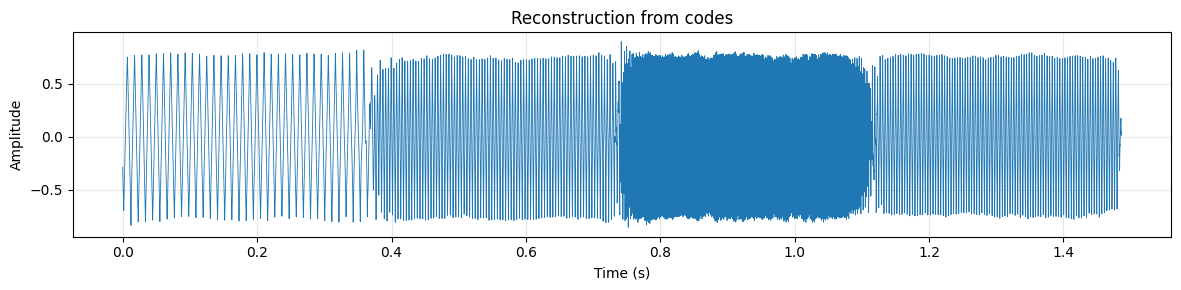

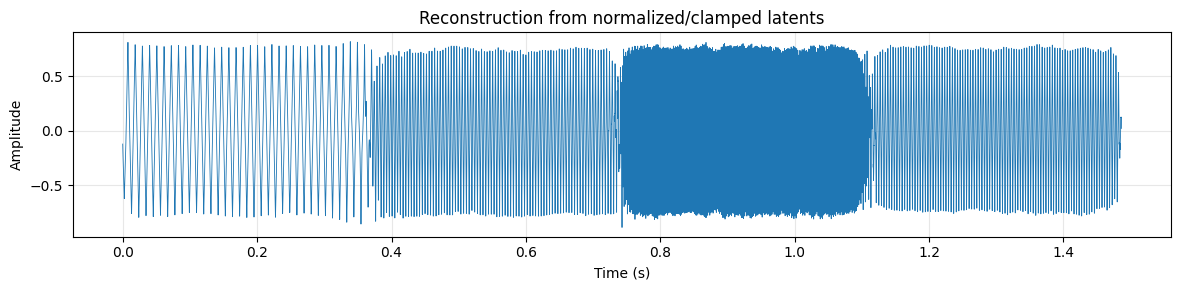

In [14]:
plot_waveform(audio_from_codes, title="Reconstruction from codes")
plot_waveform(audio_from_latents, title="Reconstruction from normalized/clamped latents")

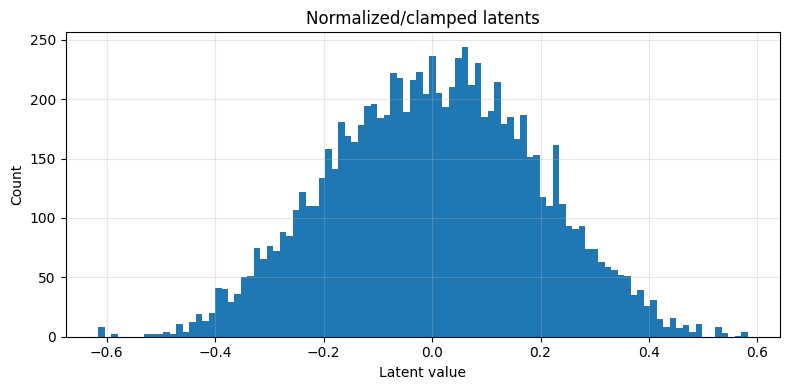

In [15]:
plot_latent_histogram_combined(latents_stacked, title="Normalized/clamped latents")

We used a clamp and normalization val on the latents of 15


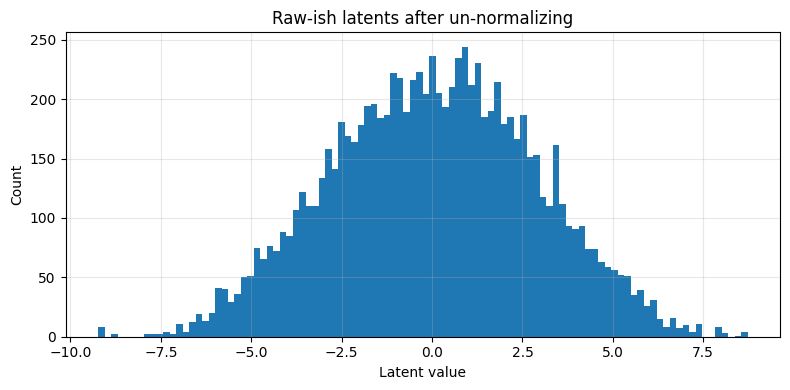

In [16]:
print(f'We used a clamp and normalization val on the latents of {ds.config.clamp_val}')
plot_latent_histogram_combined(
    latents_stacked * ds.config.clamp_val,
    title="Raw-ish latents after un-normalizing"
)

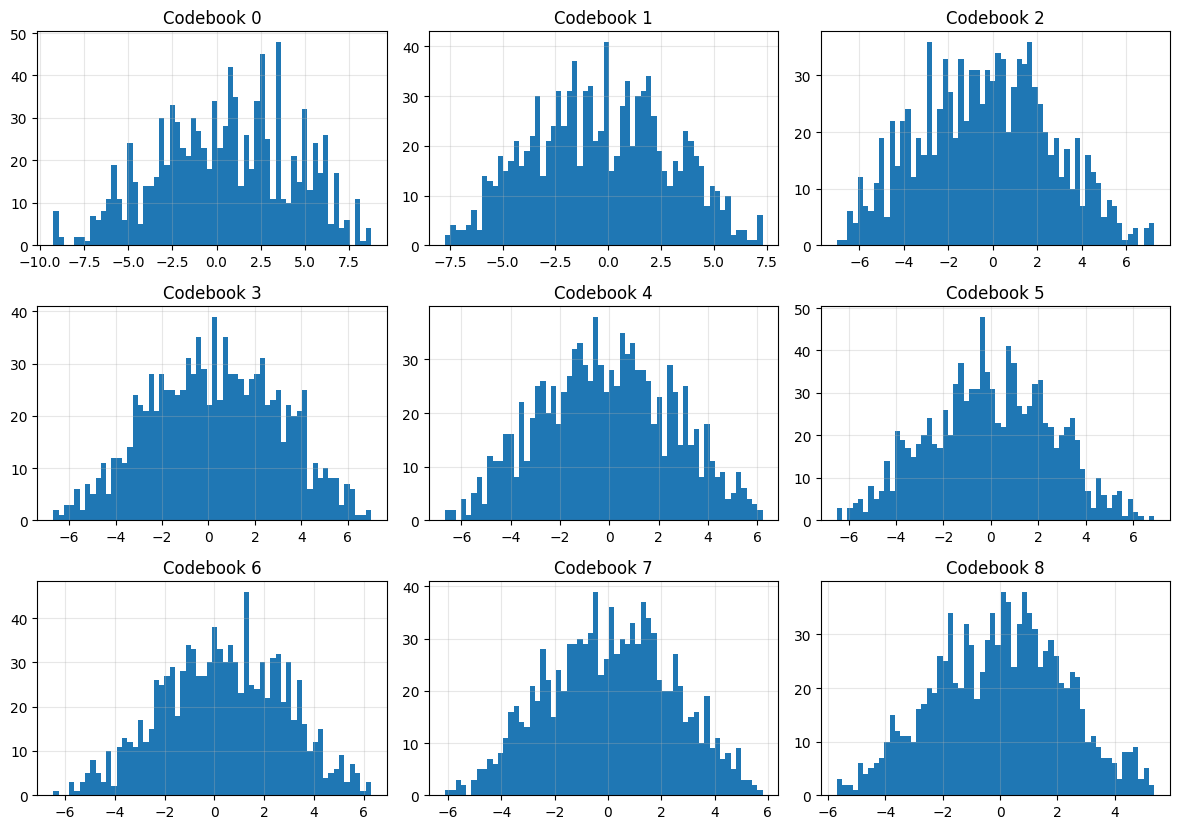

In [17]:
plot_latent_histograms_by_codebook(
    latents_stacked,
    n_q=ds.config.n_q,
    raw_scale=True,
    clamp_val=ds.config.clamp_val
)

In [18]:
vals = (latents_stacked * ds.config.clamp_val).cpu().numpy()
clipped = np.mean(np.abs(vals) >= ds.config.clamp_val)

print("Fraction clipped:", clipped)

Fraction clipped: 0.0


Original: 441000 samples, 10.0s


Decoded: 440832 samples
RMSE: 0.047780



Codebook 0 delta stats:
  Mean: 317.3
  Median: 255.0
  Max: 1001
  Frames with 0 change: 9.8%


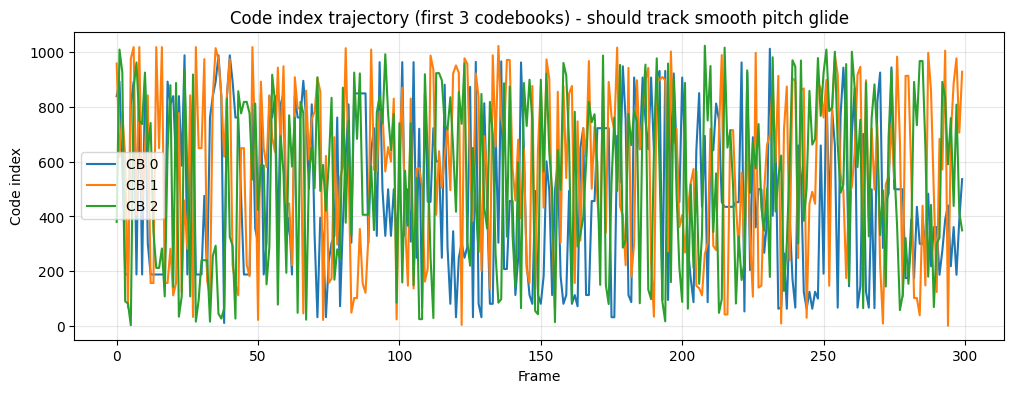

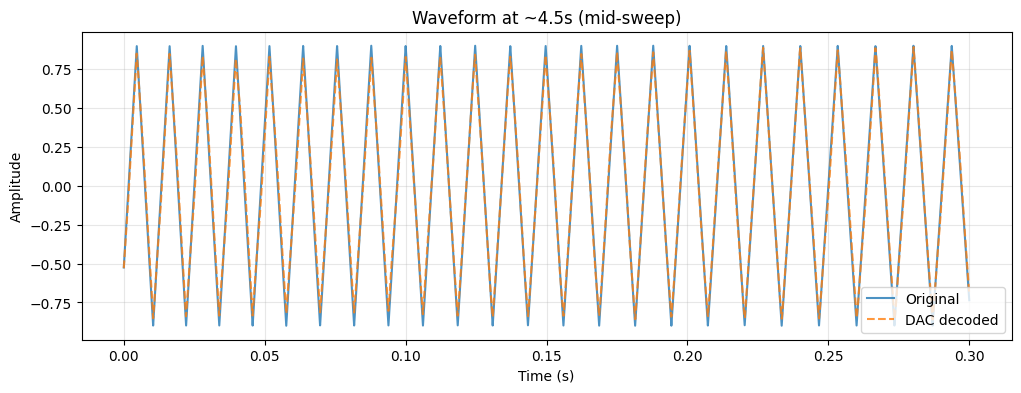

In [19]:
# -----------------------------------------------------------
# DIAGNOSTIC: Does DAC preserve a smooth pitch glide?
# Synthesize a triangle wave pitch sweep, encode/decode, compare.
# -----------------------------------------------------------

SR = 44100
duration = 10.0
n_samples = int(SR * duration)

# Triangular frequency sweep: MIDI note 36 (65.4Hz) to 84 (1008.8Hz) and back
import numpy as np
t = np.arange(n_samples) / SR
tri_frac = np.abs((t / 5.0) % 2.0 - 1.0)  # 0->1->0 over 10s
midi_note = 36.0 + (84.0 - 36.0) * tri_frac
freq_hz = 440.0 * 2.0 ** ((midi_note - 69.0) / 12.0)

# Generate triangle wave with time-varying frequency
phase = np.cumsum(2 * np.pi * freq_hz / SR)
audio_np = 2.0 * np.abs((phase / (2 * np.pi)) % 1.0 - 0.5) - 0.5  # triangle wave, [-0.5, 0.5]

# Normalize peak
peak = np.max(np.abs(audio_np))
if peak > 0:
    audio_np = 0.9 * audio_np / peak

print(f"Original: {len(audio_np)} samples, {duration:.1f}s")
ipd.display(ipd.Audio(audio_np, rate=SR))

# Encode and decode through DAC
audio_t = torch.from_numpy(audio_np).float().to(device).unsqueeze(0).unsqueeze(0)

model.eval()
with torch.no_grad():
    # DAC encode returns a tuple; find the codes
    enc = model.encode(audio_t)
    if isinstance(enc, (list, tuple)):
        z_hat = enc[0]  # quantized continuous latents (floats)
    else:
        codes = enc

    # Decode back
    audio_decoded = model.decode(z_hat)

decoded_np = audio_decoded.squeeze().detach().cpu().numpy()
print(f"Decoded: {len(decoded_np)} samples")
print(f"RMSE: {np.sqrt(np.mean((audio_np[:len(decoded_np)] - decoded_np)**2)):.6f}")

ipd.display(ipd.Audio(decoded_np, rate=SR))

# Check code smoothness
codes_t = enc[1].squeeze(0).cpu().numpy()  # integer codes for analysis
code_deltas = np.abs(np.diff(codes_t[0]))
print(f"\nCodebook 0 delta stats:")
print(f"  Mean: {code_deltas.mean():.1f}")
print(f'  Median: {np.median(code_deltas):.1f}')
print(f"  Max: {code_deltas.max()}")
print(f"  Frames with 0 change: {(code_deltas == 0).mean()*100:.1f}%")

# Plot code trajectories
plt.figure(figsize=(12, 4))
n_show = 300
for q_idx in range(3):
    plt.plot(codes_t[q_idx, :n_show], label=f'CB {q_idx}')
plt.xlabel('Frame')
plt.ylabel('Code index')
plt.title('Code index trajectory (first 3 codebooks) - should track smooth pitch glide')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Brief waveform comparison at mid-sweep
start_s = 4.5
win_s = 0.3
start_i = int(start_s * SR)
end_i = int((start_s + win_s) * SR)
plt.figure(figsize=(12, 4))
t_win = np.arange(end_i - start_i) / SR
plt.plot(t_win, audio_np[start_i:end_i], label='Original', alpha=0.8)
plt.plot(t_win, decoded_np[start_i:end_i], label='DAC decoded', alpha=0.8, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Waveform at ~{start_s}s (mid-sweep)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


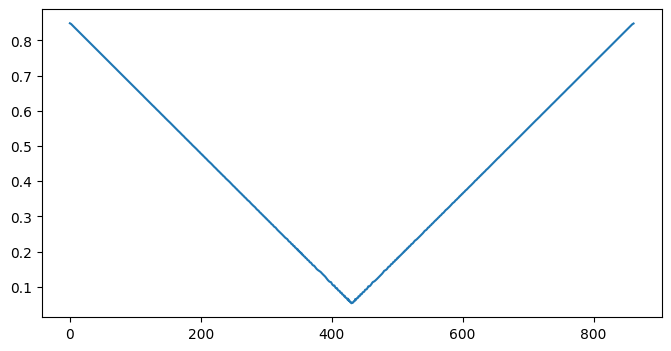

In [20]:
import librosa
f0 = librosa.yin(audio_np, fmin=55, fmax=2000, sr=44100)
mp = librosa.hz_to_midi(f0) 
norm_mp=(mp-33)/(93-33)

plt.figure(figsize=(8, 4))
plt.plot(norm_mp)
